In [1]:
# !pip install torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = sns.load_dataset('tips')

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.shape

(244, 7)

In [6]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [7]:
X = df[['total_bill', 'size']]
y = df['tip']

In [8]:
X.head()

,total_bill,size
0,16.99,2
1,10.34,3
2,21.01,3
3,23.68,2
4,24.59,4


In [9]:
y

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

In [10]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
scaler = StandardScaler()

In [12]:
X_train = scaler.fit_transform(X_train)

In [13]:
X_test = scaler.transform(X_test)

In [14]:
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

In [15]:
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

In [16]:
y_train_tensor

tensor([[ 2.7200],
        [ 2.0300],
        [ 4.0000],
        [ 4.5000],
        [ 2.0300],
        [ 3.5100],
        [ 2.0000],
        [ 5.1500],
        [ 1.7500],
        [ 2.7400],
        [ 3.0000],
        [ 5.1400],
        [ 3.5000],
        [ 5.6500],
        [ 2.5000],
        [ 2.0100],
        [ 4.0800],
        [ 2.0900],
        [ 1.0000],
        [ 3.4100],
        [ 3.4800],
        [ 2.0000],
        [ 3.0000],
        [ 2.7100],
        [ 3.0000],
        [ 3.0000],
        [ 3.0000],
        [ 3.6800],
        [ 4.7100],
        [ 3.0000],
        [ 4.2000],
        [ 1.7300],
        [ 4.0000],
        [ 3.1500],
        [ 1.5000],
        [ 3.0000],
        [ 2.0000],
        [ 2.5000],
        [ 1.5700],
        [ 3.6000],
        [ 4.3000],
        [ 3.0600],
        [ 5.9200],
        [ 1.4800],
        [ 4.3000],
        [ 3.0000],
        [ 2.6000],
        [ 4.7300],
        [ 3.5000],
        [ 4.0000],
        [ 3.0800],
        [ 2.5400],
        [ 3.

In [17]:
class TipPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        
    def forward(self, x):
        return self.network(x)

In [18]:
model = TipPredictor()
model

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [19]:
criterion = nn.MSELoss()

In [20]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [21]:
epochs = 300

loss_history = []

for epoch in range(epochs):
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch+1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [25/300], Loss: 1.3408
Epoch [50/300], Loss: 1.1474
Epoch [75/300], Loss: 1.0823
Epoch [100/300], Loss: 1.0469
Epoch [125/300], Loss: 1.0347
Epoch [150/300], Loss: 1.0244
Epoch [175/300], Loss: 1.0187
Epoch [200/300], Loss: 1.0143
Epoch [225/300], Loss: 1.0101
Epoch [250/300], Loss: 1.0061
Epoch [275/300], Loss: 1.0019
Epoch [300/300], Loss: 0.9984


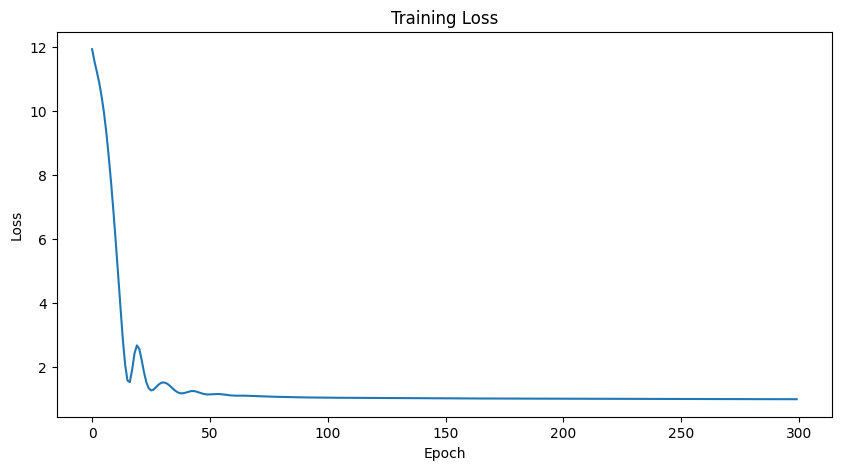

In [22]:
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [23]:
model.eval()

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [24]:
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred = y_pred.numpy()
    y_real = y_test_tensor.numpy()
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    print('Model Performance:')
    print("-" * 35)
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

Model Performance:
-----------------------------------
MAE: 0.6894
MSE: 0.7238
RMSE: 0.8507
R²: 0.4210


In [26]:
results = pd.DataFrame({
    'Actual Tip' : y_real.flatten(),
    'Predicted Tip' : y_pred.flatten()
})

In [28]:
results.head(10)

,Actual Tip,Predicted Tip
0,3.18,3.251849
1,2.00,2.042454
2,2.00,3.732074
3,5.16,3.859628
4,2.00,2.082585
5,2.00,3.018074
6,2.56,3.194408
7,2.52,2.041140
8,3.23,2.376942
9,3.00,2.481503


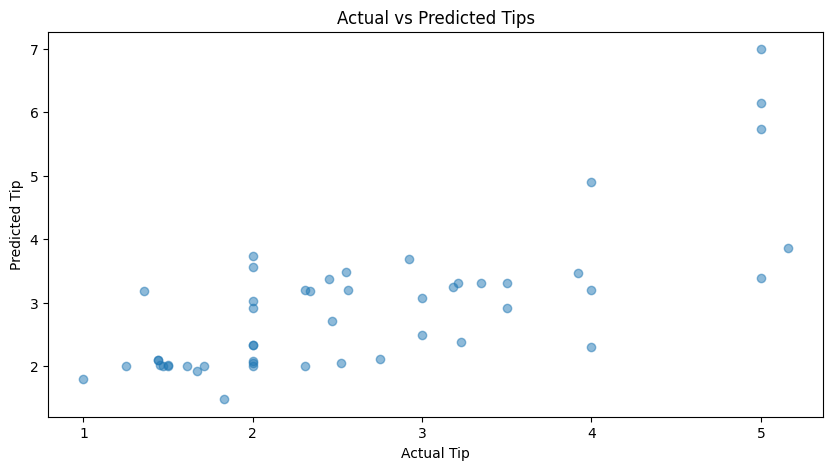

In [29]:
plt.figure(figsize=(10, 5))
plt.scatter(y_real, y_pred, alpha=0.5)
plt.xlabel('Actual Tip')
plt.ylabel('Predicted Tip')
plt.title('Actual vs Predicted Tips')
plt.show()

In [31]:
new_customer = np.array([[25.5, 2]])
new_customer = scaler.transform(new_customer)

c:\Users\N I T R O V15\.conda\envs\ga\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [32]:
new_customer_tensor = torch.FloatTensor(new_customer)

In [33]:
model.eval()

TipPredictor(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [34]:
with torch.no_grad():
    predicted_tip = model(new_customer_tensor)
    print(f"$ {predicted_tip.item():.2f} is the predicted tip for a total bill of $25.50 and a party size of 2.")

$ 3.38 is the predicted tip for a total bill of $25.50 and a party size of 2.


In [35]:
from sklearn.datasets import load_iris

In [36]:
iris = load_iris()

In [37]:
X = iris.data

In [38]:
y = iris.target

In [39]:
print('Feature Shape: ', X.shape)

Feature Shape:  (150, 4)


In [40]:
print('Target Shape: ', y.shape)

Target Shape:  (150,)


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
scaler = StandardScaler()

In [45]:
X_train = scaler.fit_transform(X_train)

In [46]:
X_test = scaler.transform(X_test)

In [47]:
X_train_tensor = torch.FloatTensor(X_train)

In [ ]:
X_test_tensor = torch.FloatTensor(X_test)

In [49]:
y_train_tensor = torch.LongTensor(y_train)

In [50]:
y_test_tensor = torch.LongTensor(y_test)

In [51]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        
    def forward(self, x):
        return self.network(x)

In [52]:
model = IrisClassifier()

In [53]:
model

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [54]:
criterion = nn.CrossEntropyLoss()

In [55]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [57]:
epochs = 300

loss_history = []
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [20/300], Loss: 0.0017
Epoch [40/300], Loss: 0.0014
Epoch [60/300], Loss: 0.0011
Epoch [80/300], Loss: 0.0009
Epoch [100/300], Loss: 0.0008
Epoch [120/300], Loss: 0.0007
Epoch [140/300], Loss: 0.0005
Epoch [160/300], Loss: 0.0005
Epoch [180/300], Loss: 0.0004
Epoch [200/300], Loss: 0.0004
Epoch [220/300], Loss: 0.0003
Epoch [240/300], Loss: 0.0003
Epoch [260/300], Loss: 0.0003
Epoch [280/300], Loss: 0.0003
Epoch [300/300], Loss: 0.0002


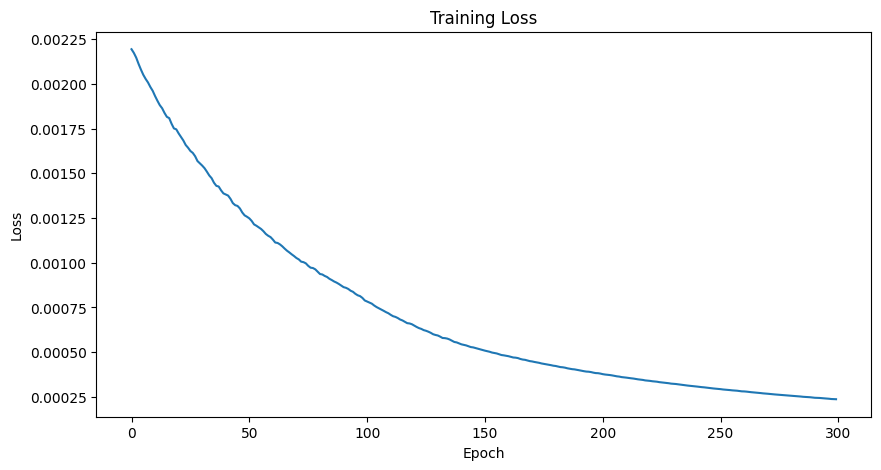

In [58]:
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [59]:
model.eval()

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [69]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [62]:
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predictions = torch.max(outputs, 1)
    accuracy = accuracy_score(y_test_tensor.numpy(), predictions.numpy())
    print(f'Test Accuracy: {accuracy:.4f}')
    cm = confusion_matrix(y_test_tensor.numpy(), predictions.numpy())
    print('Confusion Matrix:')
    print(cm)

Test Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


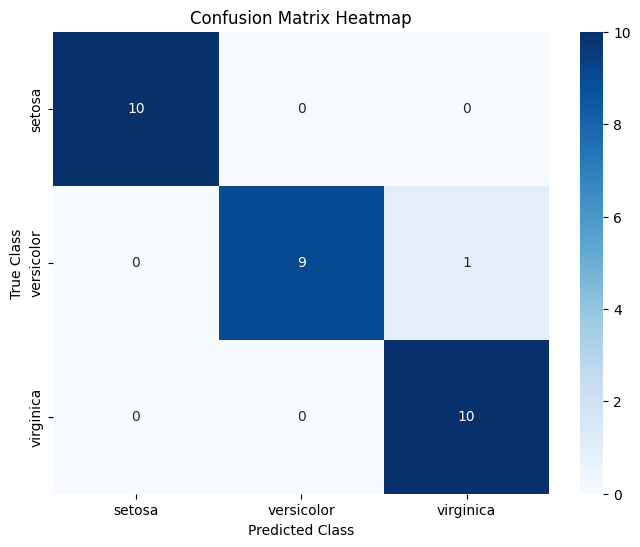

In [67]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [70]:
print('Classification Report:')
print(classification_report(y_test_tensor.numpy(), predictions.numpy(), target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [71]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
sample = scaler.transform(sample)
sample_tensor = torch.FloatTensor(sample)

In [72]:
model.eval()

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [74]:
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output, dim=1).item()
    print("Predicted Flower: ", iris.target_names[predicted_class])

Predicted Flower:  setosa
